# Milestone 3 EDA, Baseline Modeling, and Pipeline Development

## Pipeline Flow

Use this notebook as the modeling bridge between exploratory species selection and baseline experiments.

1. `01_eda.ipynb` identifies the candidate California species set.
2. `artifacts/time_geo_species_df.csv` stores the exported observation-level metadata.
3. This notebook builds reproducible train/validation/test splits and baseline datasets.
4. Trained weights are saved to `checkpoints/` so interrupted training can resume.
5. Evaluation artifacts are saved to `results/` for comparison and reporting.

In short:

`01_eda -> artifacts/time_geo_species_df.csv -> 06 notebook -> checkpoints/results`

## Summary

The goal is to establish clean baseline evidence for the central project question: how much predictive signal is available from image content, and how much is available from geography and season alone?

This notebook currently uses the image-available observation subset as the shared modeling universe. That makes image-only and geo/time-only baselines directly comparable on the same rows, but it also means the geo/time-only baseline is a matched-subset baseline rather than a full-observation geo prior. A full-observation geo baseline should be run separately from `time_geo_species_df.csv` if the research question is specifically about all available geographic observations.


## Stage 0. Environment And Paths

### Goal

Make the notebook portable across local execution and Google Colab without changing file paths by hand.

### Method

The setup cell detects whether the notebook is running in Colab, optionally mounts Google Drive, finds the project root, and defines shared paths for data, artifacts, checkpoints, results, and images.

### Output

All later stages use the same path variables, so training can save checkpoints to `checkpoints/` and evaluation can save figures or JSON files to `results/` consistently.


In [1]:
import os
import sys
import json
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_OVERRIDE = os.environ.get("CANOPY_REPO_ROOT")

if IN_COLAB:
    from google.colab import drive
    if os.environ.get("CANOPY_SKIP_DRIVE_MOUNT", "0") != "1":
        drive.mount("/content/drive", force_remount=False)


def find_repo_root() -> Path:
    candidates = []

    if REPO_OVERRIDE:
        candidates.append(Path(REPO_OVERRIDE).expanduser())

    if IN_COLAB:
        candidates.extend(
            [
                Path("/content/Final_project_109B"),
                Path("/content/drive/MyDrive/Final_project_109B"),
                Path.cwd(),
            ]
        )
    else:
        candidates.extend([Path.cwd(), Path.cwd().parent])

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        for root in [candidate, *candidate.parents]:
            if root in seen:
                continue
            seen.add(root)
            if (root / "notebooks").exists() and ((root / "requirements.txt").exists() or (root / "README.md").exists()):
                return root

    raise FileNotFoundError(
        "Could not locate the Canopy project root. Set CANOPY_REPO_ROOT if needed."
    )


PROJECT_ROOT = find_repo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
IMAGES_DIR = DATA_DIR / "images"
MASTER_DF_PATH = ARTIFACTS_DIR / "master_observations.csv"
IID_SPLIT_PATH = ARTIFACTS_DIR / "split_iid.csv"
SPATIAL_SPLIT_PATH = ARTIFACTS_DIR / "split_spatial.csv"
TIME_GEO_SPECIES_PATH = ARTIFACTS_DIR / "time_geo_species_df.csv"
LABEL_ENCODER_PATH = ARTIFACTS_DIR / "label_encoder.pkl"
LABEL_MAPPING_PATH = ARTIFACTS_DIR / "label_mapping.json"
IMAGE_METADATA_PATH = DATA_DIR / "image_metadata.csv"

for path in [DATA_DIR, ARTIFACTS_DIR, CHECKPOINTS_DIR, RESULTS_DIR, IMAGES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if IN_COLAB and (PROJECT_ROOT / "requirements.txt").exists():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")])

os.chdir(NOTEBOOKS_DIR)

print(f"IN_COLAB={IN_COLAB}")
print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"NOTEBOOKS_DIR={NOTEBOOKS_DIR}")
print(f"DATA_DIR={DATA_DIR}")
print(f"ARTIFACTS_DIR={ARTIFACTS_DIR}")
print(f"CHECKPOINTS_DIR={CHECKPOINTS_DIR}")
print(f"RESULTS_DIR={RESULTS_DIR}")
print(f"IMAGES_DIR={IMAGES_DIR}")
print(f"cwd={Path.cwd()}")

# Training cells always enter the model trainer. The trainer decides whether to
# resume an unfinished checkpoint or load a completed checkpoint for evaluation.


Mounted at /content/drive
IN_COLAB=True
PROJECT_ROOT=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B
NOTEBOOKS_DIR=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/notebooks
DATA_DIR=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/data
ARTIFACTS_DIR=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/artifacts
CHECKPOINTS_DIR=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/checkpoints
RESULTS_DIR=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/results
IMAGES_DIR=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/data/images
cwd=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/notebooks


## Stage 1. Imports And Shared Utilities

### Goal

Load the scientific Python, PyTorch, image-processing, and scikit-learn tools needed for the complete baseline pipeline.

### Method

The imports are grouped once near the top of the notebook. Small helper functions summarize splits and verify species coverage, which makes it easier to catch split leakage or class-coverage problems before training.

### Output

The notebook has one shared utility layer for summaries, display settings, tensor datasets, image transforms, models, and evaluation helpers.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import joblib

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def summarize_split(df, split_col="split_iid", label_col="species"):
    summary = (
        df.groupby(split_col)
        .agg(
            observations=(label_col, "size"),
            species_count=(label_col, "nunique"),
        )
        .reset_index()
    )
    display(summary)
    return summary


def print_species_coverage(df, split_col="split_iid"):
    coverage = (
        df.groupby([split_col, "species"]).size().unstack(fill_value=0)
    )
    display(coverage.head())
    print(f"Total species columns: {coverage.shape[1]}")
    return coverage


## Stage 2. Load Exported EDA Output

### Goal

Load the observation metadata and image metadata needed to build the modeling dataset.

### Method

The observation table comes from `artifacts/time_geo_species_df.csv`, which was exported by the EDA workflow. The image metadata comes from `data/image_metadata.csv`, which indexes downloaded image files and their associated observation metadata.

### Output

This stage provides two raw inputs: a large observation-level geo/time table and an image-available subset. The later merge determines the exact universe used for the matched baseline comparison.


In [3]:
EDA_NOTEBOOK_PATH = NOTEBOOKS_DIR / "01_eda.ipynb"

print(f"TIME_GEO_SPECIES_PATH={TIME_GEO_SPECIES_PATH}")
print(f"IMAGE_METADATA_PATH={IMAGE_METADATA_PATH}")

if not TIME_GEO_SPECIES_PATH.exists():
    raise FileNotFoundError(
        "artifacts/time_geo_species_df.csv not found. Run the safe export cell in 01_eda.ipynb first."
    )

if not IMAGE_METADATA_PATH.exists():
    raise FileNotFoundError(
        "data/image_metadata.csv not found. Build or copy it before training image-based models."
    )

# Optional fallback only. Leave commented in the main workflow.
# if EDA_NOTEBOOK_PATH.exists():
#     print("Running 01_eda.ipynb to rebuild time_geo_species_df...")
#     get_ipython().run_line_magic("run", "01_eda.ipynb")
# else:
#     print("01_eda.ipynb not found.")

TIME_GEO_SPECIES_PATH=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/artifacts/time_geo_species_df.csv
IMAGE_METADATA_PATH=/content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/data/image_metadata.csv


In [4]:
obs_df = pd.read_csv(TIME_GEO_SPECIES_PATH)
img_df_raw = pd.read_csv(IMAGE_METADATA_PATH)

print(f"Observation table shape: {obs_df.shape}")
print(f"Image metadata shape: {img_df_raw.shape}")
display(obs_df.head())
display(img_df_raw.head())


Observation table shape: (108070, 40)
Image metadata shape: (4400, 8)


,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,infraspecificEpithet,taxonRank,scientificName,verbatimScientificName,countryCode,stateProvince,occurrenceStatus,publishingOrgKey,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,eventDate,day,month,year,taxonKey,speciesKey,basisOfRecord,institutionCode,collectionCode,catalogNumber,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,lastInterpreted,mediaType,issue,doy
0,5828303915,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/21869...,Plantae,Tracheophyta,Magnoliopsida,Apiales,Apiaceae,Foeniculum,Foeniculum vulgare,NaN,SPECIES,Foeniculum vulgare Mill.,Foeniculum vulgare,US,California,PRESENT,28eb1a3f-1c15-4a95-931a-4af90ecb574d,38.599064,-121.508266,NaN,2024-05-19T15:48:42,19,5,2024,3034922,3034922.0,HUMAN_OBSERVATION,iNaturalist,Observations,218699999,Colin J Pryor,2024-05-27T18:16:19,CC_BY_4_0,Colin J Pryor,Colin J Pryor,2026-03-20T16:13:40.255Z,StillImage;StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,169
1,4952638799,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/23998...,Plantae,Tracheophyta,Magnoliopsida,Asterales,Asteraceae,Baccharis,Baccharis pilularis,NaN,SPECIES,Baccharis pilularis DC.,Baccharis pilularis,US,California,PRESENT,28eb1a3f-1c15-4a95-931a-4af90ecb574d,36.682769,-121.780139,4.0,2024-09-05T09:15:36,5,9,2024,3129497,3129497.0,HUMAN_OBSERVATION,iNaturalist,Observations,239984236,yerbasanta,2024-10-01T23:35:18,CC_BY_NC_4_0,sophiepod,sophiepod,2026-03-20T18:59:57.593Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,275
2,4420921807,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/18377...,Plantae,Tracheophyta,Liliopsida,Poales,Poaceae,Cenchrus,Cenchrus setaceus,NaN,SPECIES,Cenchrus setaceus (Forssk.) Morrone,Cenchrus setaceus,US,California,PRESENT,28eb1a3f-1c15-4a95-931a-4af90ecb574d,34.117147,-117.227225,20.0,2023-09-17T18:23:48,17,9,2023,5828232,5828232.0,HUMAN_OBSERVATION,iNaturalist,Observations,183778655,Jessica L,2023-09-18T01:25:35,CC_BY_NC_4_0,Jessica L,Jessica L,2026-03-20T18:49:51.641Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,287
3,5007141157,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/25657...,Plantae,Tracheophyta,Magnoliopsida,Asterales,Asteraceae,Baccharis,Baccharis pilularis,NaN,SPECIES,Baccharis pilularis DC.,Baccharis pilularis,US,California,PRESENT,28eb1a3f-1c15-4a95-931a-4af90ecb574d,38.513578,-122.736141,NaN,2024-12-24T09:40:45,24,12,2024,3129497,3129497.0,HUMAN_OBSERVATION,iNaturalist,Observations,256574267,bio5444,2024-12-29T02:09:59,CC_BY_NC_4_0,bio5444,bio5444,2026-03-20T16:24:59.636Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,384
4,4597337952,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/20174...,Plantae,Tracheophyta,Magnoliopsida,Apiales,Apiaceae,Sanicula,Sanicula arctopoides,NaN,SPECIES,Sanicula arctopoides Hook. & Arn.,Sanicula arctopoides,US,California,PRESENT,28eb1a3f-1c15-4a95-931a-4af90ecb574d,37.990488,-122.965928,4.0,2024-03-08T15:15:46,8,3,2024,3034853,3034853.0,HUMAN_OBSERVATION,iNaturalist,Observations,201740501,phoca2004,2024-03-09T01:47:54,CC_BY_NC_4_0,phoca2004,phoca2004,2026-03-20T18:53:15.314Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,98


,gbifID,occurrenceID,species,decimalLatitude,decimalLongitude,doy,label_species,image_path
0,3499604985,https://www.inaturalist.org/observations/10683...,Achillea millefolium,35.337153,-120.809411,75,0,/Users/nehasajja/Documents/DS26_Final/plant-ge...
1,3902514877,https://www.inaturalist.org/observations/13141...,Achillea millefolium,39.650803,-120.658164,254,0,/Users/nehasajja/Documents/DS26_Final/plant-ge...
2,3859065345,https://www.inaturalist.org/observations/11901...,Achillea millefolium,37.439089,-122.360247,177,0,/Users/nehasajja/Documents/DS26_Final/plant-ge...
3,4440916849,https://www.inaturalist.org/observations/19044...,Achillea millefolium,40.786529,-124.097679,338,0,/Users/nehasajja/Documents/DS26_Final/plant-ge...
4,3860112650,https://www.inaturalist.org/observations/12276...,Achillea millefolium,34.356561,-117.851273,200,0,/Users/nehasajja/Documents/DS26_Final/plant-ge...


## Stage 3. Build The Unified Master Observation Table

### Goal

Create one row-level source of truth for experiments that require both image data and geo/time metadata.

### Method

The notebook keeps valid observation fields from the exported EDA table, fixes image paths to point to the local project image directory, verifies that files exist, and inner-joins observations to the image metadata by `gbifID`.

### Inclusion Rules

An observation remains in `master_df` only if it has a valid species label, valid latitude and longitude, valid day-of-year, an image metadata record, and an image file that exists on disk.

### Important Caveat

Because this stage inner-joins with `image_metadata.csv`, `master_df` is the image-available subset. In the current downloaded dataset, image metadata was sampled at about 100 images per species. That is appropriate for matched image-vs-geo comparisons, but it is not the same as training a geo baseline on all available observations.


In [5]:
obs_keep_cols = [
    "gbifID",
    "occurrenceID",
    "species",
    "decimalLatitude",
    "decimalLongitude",
    "doy",
]

obs_base = obs_df[obs_keep_cols].copy()
obs_base = obs_base.dropna(subset=["gbifID", "species", "decimalLatitude", "decimalLongitude", "doy"])
obs_base = obs_base[obs_base["doy"].between(1, 365)].copy()
obs_base["gbifID"] = obs_base["gbifID"].astype(str)

img_df = img_df_raw.copy()
img_df["gbifID"] = img_df["gbifID"].astype(str)


def fix_to_absolute(path, images_root):
    p = Path(path)
    if p.is_absolute() and p.exists():
        return str(p)

    parts = p.parts
    if "images" in parts:
        images_idx = parts.index("images")
        relative = Path(*parts[images_idx + 1 :])
        return str(images_root / relative)

    if len(parts) >= 2:
        return str(images_root / Path(*parts[-2:]))

    return str(images_root / p)


img_df["image_path"] = img_df["image_path"].apply(lambda p: fix_to_absolute(p, IMAGES_DIR))
img_df["file_exists"] = img_df["image_path"].apply(lambda p: Path(p).exists())

master_df = obs_base.merge(
    img_df[["gbifID", "image_path", "file_exists"]].drop_duplicates(subset=["gbifID"]),
    on="gbifID",
    how="inner",
)

master_df = master_df[master_df["file_exists"]].copy()
master_df = master_df.drop_duplicates(subset=["gbifID"])
master_df = master_df.reset_index(drop=True)

print(f"master_df shape: {master_df.shape}")
print(f"species: {master_df['species'].nunique()}")
print(f"missing image_path: {master_df['image_path'].isna().sum()}")
display(master_df.head())


master_df shape: (4400, 8)
species: 44
missing image_path: 0


,gbifID,occurrenceID,species,decimalLatitude,decimalLongitude,doy,image_path,file_exists
0,4420921807,https://www.inaturalist.org/observations/18377...,Cenchrus setaceus,34.117147,-117.227225,287,/content/drive/.shortcut-targets-by-id/14mf7ED...,True
1,4974165223,https://www.inaturalist.org/observations/24801...,Encelia californica,33.726984,-118.345309,312,/content/drive/.shortcut-targets-by-id/14mf7ED...,True
2,4430517410,https://www.inaturalist.org/observations/18550...,Cortaderia selloana,37.939358,-122.529053,299,/content/drive/.shortcut-targets-by-id/14mf7ED...,True
3,4875585751,https://www.inaturalist.org/observations/21824...,Daucus pusillus,38.741772,-121.148106,175,/content/drive/.shortcut-targets-by-id/14mf7ED...,True
4,4413709459,https://www.inaturalist.org/observations/18272...,Heracleum maximum,36.772001,-118.341671,279,/content/drive/.shortcut-targets-by-id/14mf7ED...,True


In [6]:
master_df.to_csv(MASTER_DF_PATH, index=False)
print(f"Saved master_df to {MASTER_DF_PATH}")

Saved master_df to /content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/artifacts/master_observations.csv


### Quick EDA On The Master Table

### Goal

Verify that the final modeling universe is reasonable before creating splits or fitting models.

### Method

The summary checks the distribution of species labels, latitude, longitude, and day-of-year after filtering and merging. This is a lightweight checkpoint, not a replacement for the full EDA notebook.

### Output

If the table shape, species coverage, or coordinate/time ranges look wrong here, training results downstream should not be trusted until the data issue is fixed.


,species,decimalLatitude,decimalLongitude,doy
count,4400,4400.000000,4400.000000,4400.000000
unique,44,NaN,NaN,NaN
top,Cenchrus setaceus,NaN,NaN,NaN
freq,100,NaN,NaN,NaN
mean,NaN,36.164378,-120.026837,185.502045
std,NaN,2.488719,2.442454,83.868365
min,NaN,32.540529,-124.361892,31.000000
25%,NaN,33.806579,-122.128732,122.000000
50%,NaN,36.507531,-120.530016,170.000000
75%,NaN,38.131551,-117.633781,248.000000


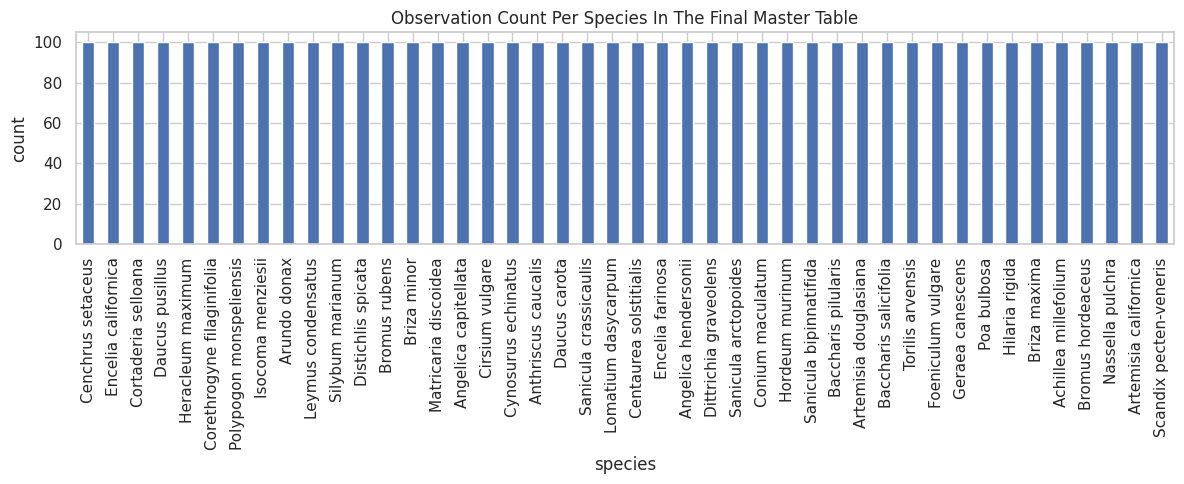

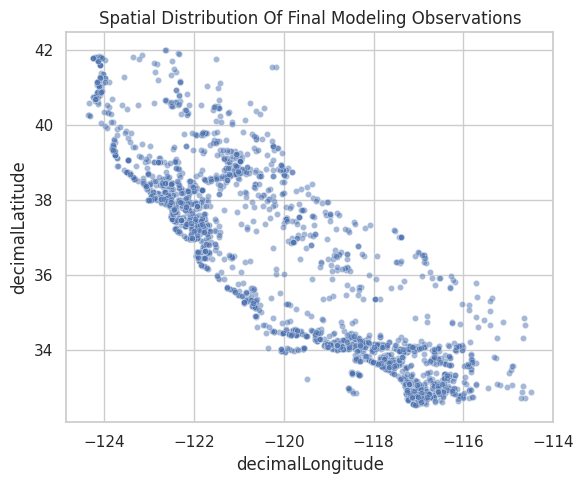

In [7]:
display(master_df[["species", "decimalLatitude", "decimalLongitude", "doy"]].describe(include="all"))

species_counts = master_df["species"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
species_counts.plot(kind="bar")
plt.title("Observation Count Per Species In The Final Master Table")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=master_df.sample(min(len(master_df), 3000), random_state=42), x="decimalLongitude", y="decimalLatitude", alpha=0.5, s=20)
plt.title("Spatial Distribution Of Final Modeling Observations")
plt.tight_layout()
plt.show()


## Stage 4. Create One Main IID Split

### Goal

Create a single train/validation/test split that can be reused across the matched baselines.

### Method

The notebook uses a stratified random split at the observation level: 70% train, 15% validation, and 15% test. Stratification by species preserves class representation across splits.

### Output

The resulting split is saved to `artifacts/split_iid.csv`. Every downstream dataset is derived from the same split labels, which makes the image-only and matched geo/time-only baselines directly comparable.

### Interpretation Note

Because the current image subset has roughly 100 observations per species, a 15% validation or test split produces about 15 examples per species. Per-species accuracy therefore moves in coarse 6.7 percentage-point steps, so class-level results should be interpreted cautiously.


In [8]:
RANDOM_STATE = 42

train_df, temp_df = train_test_split(
    master_df,
    test_size=0.30,
    stratify=master_df["species"],
    random_state=RANDOM_STATE,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["species"],
    random_state=RANDOM_STATE,
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split_iid"] = "train"
val_df["split_iid"] = "val"
test_df["split_iid"] = "test"

master_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

split_export = master_df[["gbifID", "species", "split_iid"]].copy()
split_export.to_csv(IID_SPLIT_PATH, index=False)

summarize_split(master_df)
coverage = print_species_coverage(master_df)
print(f"Saved IID split to {IID_SPLIT_PATH}")


,split_iid,observations,species_count
0,test,660,44
1,train,3080,44
2,val,660,44


species,Achillea millefolium,Angelica capitellata,Angelica hendersonii,Anthriscus caucalis,Artemisia californica,Artemisia douglasiana,Arundo donax,Baccharis pilularis,Baccharis salicifolia,Briza maxima,Briza minor,Bromus hordeaceus,Bromus rubens,Cenchrus setaceus,Centaurea solstitialis,Cirsium vulgare,Conium maculatum,Corethrogyne filaginifolia,Cortaderia selloana,Cynosurus echinatus,Daucus carota,Daucus pusillus,Distichlis spicata,Dittrichia graveolens,Encelia californica,Encelia farinosa,Foeniculum vulgare,Geraea canescens,Heracleum maximum,Hilaria rigida,Hordeum murinum,Isocoma menziesii,Leymus condensatus,Lomatium dasycarpum,Matricaria discoidea,Nassella pulchra,Poa bulbosa,Polypogon monspeliensis,Sanicula arctopoides,Sanicula bipinnatifida,Sanicula crassicaulis,Scandix pecten-veneris,Silybum marianum,Torilis arvensis
split_iid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
test,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15
train,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70,70
val,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15


Total species columns: 44
Saved IID split to /content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/artifacts/split_iid.csv


## Stage 5. Labels And Feature Engineering

### Goal

Create a shared class label space and encode location/season as numeric model features.

### Method

The `LabelEncoder` is fit on the training split and applied to validation and test rows. Latitude, longitude, and day-of-year are encoded with sine and cosine transforms, producing six metadata features: `lat_sin`, `lat_cos`, `lon_sin`, `lon_cos`, `doy_sin`, and `doy_cos`.

### Why This Encoding

Sinusoidal encoding keeps cyclic structure for day-of-year and gives bounded numeric inputs for coordinates. It also avoids fitting a scaler on the full dataset, which reduces the chance of leakage.

### Output

This stage writes the label encoder and label mapping to `artifacts/`, and it appends the six geo/time feature columns to the split dataframes.


In [9]:
GEO_FEATURE_COLS = ["lat_sin", "lat_cos", "lon_sin", "lon_cos", "doy_sin", "doy_cos"]
GEO_TARGET_COL = "label_species"


def sinusoidal_encode(df):
    enc = pd.DataFrame(index=df.index)
    lat_norm = df["decimalLatitude"] / 90.0
    lon_norm = df["decimalLongitude"] / 180.0
    doy_norm = (df["doy"] - 183) / 183.0

    enc["lat_sin"] = np.sin(np.pi * lat_norm)
    enc["lat_cos"] = np.cos(np.pi * lat_norm)
    enc["lon_sin"] = np.sin(np.pi * lon_norm)
    enc["lon_cos"] = np.cos(np.pi * lon_norm)
    enc["doy_sin"] = np.sin(np.pi * doy_norm)
    enc["doy_cos"] = np.cos(np.pi * doy_norm)
    return enc


for split_name in ["train", "val", "test"]:
    mask = master_df["split_iid"] == split_name
    master_df.loc[mask, GEO_FEATURE_COLS] = sinusoidal_encode(master_df.loc[mask])

le = LabelEncoder()
train_mask = master_df["split_iid"] == "train"

master_df.loc[train_mask, GEO_TARGET_COL] = le.fit_transform(master_df.loc[train_mask, "species"])
master_df.loc[~train_mask, GEO_TARGET_COL] = le.transform(master_df.loc[~train_mask, "species"])
master_df[GEO_TARGET_COL] = master_df[GEO_TARGET_COL].astype(int)

joblib.dump(le, LABEL_ENCODER_PATH)
with open(LABEL_MAPPING_PATH, "w") as f:
    json.dump(dict(enumerate(le.classes_)), f, indent=2)

print(f"Classes: {len(le.classes_)}")
print(f"Saved label encoder to {LABEL_ENCODER_PATH}")
display(master_df.head())


Classes: 44
Saved label encoder to /content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/artifacts/label_encoder.pkl


,gbifID,occurrenceID,species,decimalLatitude,decimalLongitude,doy,image_path,file_exists,split_iid,lat_sin,lat_cos,lon_sin,lon_cos,doy_sin,doy_cos,label_species
0,5166817590,https://www.inaturalist.org/observations/20086...,Bromus rubens,33.598145,-117.762550,89,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.921838,0.387575,-0.884886,-0.465808,-0.999079,-0.042905,12
1,4945552183,https://www.inaturalist.org/observations/24152...,Centaurea solstitialis,39.488280,-121.882562,283,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.981549,0.191211,-0.849132,-0.528180,0.989372,-0.145404,14
2,4133841801,https://www.inaturalist.org/observations/16523...,Sanicula crassicaulis,41.055678,-124.149876,182,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.990537,0.137248,-0.827572,-0.561360,-0.017166,0.999853,40
3,4145438206,https://www.inaturalist.org/observations/17074...,Daucus carota,40.946515,-124.100620,212,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.990007,0.141022,-0.828054,-0.560648,0.477536,0.878612,20
4,3988626971,https://www.inaturalist.org/observations/14353...,Arundo donax,33.969371,-117.436306,362,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.926783,0.375598,-0.887524,-0.460762,0.068615,-0.997643,6


## Stage 6. Derive Model-Specific Tables From The Same Split

### Goal

Separate the unified master table into model-ready train, validation, and test dataframes.

### Method

Rows are filtered by the `split_iid` label created in Stage 4. No new random split is created here.

### Output

The notebook now has `train_df`, `val_df`, and `test_df` that carry image paths, species labels, encoded geo/time features, and split membership. These dataframes feed the geo/time-only, image-only, and future multimodal datasets.


In [10]:
train_df = master_df[master_df["split_iid"] == "train"].copy()
val_df = master_df[master_df["split_iid"] == "val"].copy()
test_df = master_df[master_df["split_iid"] == "test"].copy()

print(train_df.shape, val_df.shape, test_df.shape)
display(train_df.head())


(3080, 16) (660, 16) (660, 16)


,gbifID,occurrenceID,species,decimalLatitude,decimalLongitude,doy,image_path,file_exists,split_iid,lat_sin,lat_cos,lon_sin,lon_cos,doy_sin,doy_cos,label_species
0,5166817590,https://www.inaturalist.org/observations/20086...,Bromus rubens,33.598145,-117.762550,89,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.921838,0.387575,-0.884886,-0.465808,-0.999079,-0.042905,12
1,4945552183,https://www.inaturalist.org/observations/24152...,Centaurea solstitialis,39.488280,-121.882562,283,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.981549,0.191211,-0.849132,-0.528180,0.989372,-0.145404,14
2,4133841801,https://www.inaturalist.org/observations/16523...,Sanicula crassicaulis,41.055678,-124.149876,182,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.990537,0.137248,-0.827572,-0.561360,-0.017166,0.999853,40
3,4145438206,https://www.inaturalist.org/observations/17074...,Daucus carota,40.946515,-124.100620,212,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.990007,0.141022,-0.828054,-0.560648,0.477536,0.878612,20
4,3988626971,https://www.inaturalist.org/observations/14353...,Arundo donax,33.969371,-117.436306,362,/content/drive/.shortcut-targets-by-id/14mf7ED...,True,train,0.926783,0.375598,-0.887524,-0.460762,0.068615,-0.997643,6


## Stage 7. Geo/Time-Only Baseline Dataset

### Goal

Measure how much species information is present in location and season alone, without image pixels.

### Method

The validation and test tensors are created once from the six geo/time features. The training loader is rebuilt inside each epoch with `sample_epoch()`, which caps the number of training examples per species to reduce class imbalance while preserving real observations.

### Output

This stage produces `geo_val_loader`, `geo_test_loader`, and class weights for weighted cross-entropy. In the current matched subset, validation/test counts are small per species; for a full geo prior baseline, this stage should be rebuilt from the full observation table rather than the image subset.


In [11]:
BATCH_SIZE = 1024
CAP_PER_SPECIES = 500


def to_tensors(df):
    X = torch.tensor(df[GEO_FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df[GEO_TARGET_COL].values, dtype=torch.long)
    return X, y


def sample_epoch(df, feature_cols, target_col, cap=CAP_PER_SPECIES):
    sampled_parts = []
    for label in sorted(df[target_col].unique()):
        group = df[df[target_col] == label]
        n = min(len(group), cap)
        sampled_parts.append(group.sample(n=n, random_state=None))
    sampled = pd.concat(sampled_parts, ignore_index=True).sample(frac=1).reset_index(drop=True)
    X = torch.tensor(sampled[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(sampled[target_col].values, dtype=torch.long)
    return X, y


X_val, y_val = to_tensors(val_df)
X_test, y_test = to_tensors(test_df)

geo_val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
geo_test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

species_counts = train_df[GEO_TARGET_COL].value_counts().sort_index()
class_weights = 1.0 / torch.tensor(species_counts.values, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_weights)

print(f"Geo train observations: {len(train_df)}")
print(f"Geo val observations: {len(val_df)}")
print(f"Geo test observations: {len(test_df)}")


Geo train observations: 3080
Geo val observations: 660
Geo test observations: 660


## Stage 8. Image-Only Baseline Dataset

### Goal

Create an image-only baseline that predicts species from pixels alone.

### Method

The dataset reads image files from disk, applies training-time augmentation to the train split, and deterministic resizing/cropping to validation and test splits. Labels come from the same encoder used by the geo/time baseline.

### Output

The result is a set of PyTorch datasets and dataloaders for ResNet50 fine-tuning. Because the same split rows are used as the matched geo/time baseline, differences in performance mainly reflect the information content of the inputs rather than split differences.


In [12]:
IMG_SIZE = 224
IMG_BATCH_SIZE = 32
IMAGE_NUM_WORKERS = 2 if IN_COLAB else 0
IMAGE_PIN_MEMORY = DEVICE.type == "cuda" if "DEVICE" in globals() else False

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class PlantImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row[GEO_TARGET_COL], dtype=torch.long)
        return image, label

    def get_metadata(self, idx):
        return self.df.iloc[idx]


train_image_dataset = PlantImageDataset(train_df, transform=train_transforms)
val_image_dataset = PlantImageDataset(val_df, transform=eval_transforms)
test_image_dataset = PlantImageDataset(test_df, transform=eval_transforms)

train_image_loader = DataLoader(train_image_dataset, batch_size=IMG_BATCH_SIZE, shuffle=True, num_workers=IMAGE_NUM_WORKERS, pin_memory=IMAGE_PIN_MEMORY)
val_image_loader = DataLoader(val_image_dataset, batch_size=IMG_BATCH_SIZE, shuffle=False, num_workers=IMAGE_NUM_WORKERS, pin_memory=IMAGE_PIN_MEMORY)
test_image_loader = DataLoader(test_image_dataset, batch_size=IMG_BATCH_SIZE, shuffle=False, num_workers=IMAGE_NUM_WORKERS, pin_memory=IMAGE_PIN_MEMORY)

sample_image, sample_label = train_image_dataset[0]
print(sample_image.shape, sample_label)
print(f"Image workers: {IMAGE_NUM_WORKERS} | pin_memory: {IMAGE_PIN_MEMORY}")
print(f"Image train/val/test sizes: {len(train_image_dataset)}, {len(val_image_dataset)}, {len(test_image_dataset)}")
print(f"Image train/val/test batches: {len(train_image_loader)}, {len(val_image_loader)}, {len(test_image_loader)}")

sample_paths = train_df["image_path"].head(5).tolist()
missing_paths = [p for p in sample_paths if not Path(p).exists()]
if missing_paths:
    print("Warning: sample training image paths are missing:")
    for p in missing_paths:
        print(p)
else:
    print("Sample training image paths resolved successfully.")


torch.Size([3, 224, 224]) tensor(12)
Image workers: 2 | pin_memory: False
Image train/val/test sizes: 3080, 660, 660
Image train/val/test batches: 97, 21, 21
Sample training image paths resolved successfully.


## Stage 9. Multimodal-Ready Dataset Class

### Goal

Prepare the data interface needed for a future model that consumes both images and geo/time metadata.

### Method

The dataset returns three items per row: the transformed image tensor, the six-dimensional geo/time feature vector, and the species label.

### Output

This stage does not train a multimodal model yet. It validates that the notebook can produce aligned image and context inputs from the same observation row, which is the key requirement for the next modeling milestone.


In [13]:
class PlantMultimodalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        geo_features = torch.tensor(row[GEO_FEATURE_COLS].values.astype(np.float32), dtype=torch.float32)
        label = torch.tensor(row[GEO_TARGET_COL], dtype=torch.long)
        return image, geo_features, label


train_multi_dataset = PlantMultimodalDataset(train_df, transform=train_transforms)
val_multi_dataset = PlantMultimodalDataset(val_df, transform=eval_transforms)
test_multi_dataset = PlantMultimodalDataset(test_df, transform=eval_transforms)

img, geo_vec, y = train_multi_dataset[0]
print(img.shape, geo_vec.shape, y)


torch.Size([3, 224, 224]) torch.Size([6]) tensor(12)


## Stage 10. Devices And Shared Training Helpers

### Goal

Select the best available compute device and define reusable evaluation logic.

### Method

The notebook prefers Apple MPS when available, then CUDA, then CPU. The shared evaluator supports both tensor-only batches and image batches, computes loss and accuracy, and stores predictions and labels for per-class analysis.

### Output

All model sections use the same evaluation contract, which keeps result reporting comparable across baselines.


In [14]:
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")


def evaluate_classifier(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 2:
                X, y = batch
                X = X.to(device)
                y = y.to(device)
                outputs = model(X)
            else:
                images, y = batch
                images = images.to(device)
                y = y.to(device)
                outputs = model(images)

            loss = criterion(outputs, y)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * y.size(0)
            total_correct += (preds == y).sum().item()
            total_examples += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return {
        "loss": total_loss / total_examples,
        "acc": total_correct / total_examples,
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
    }


Using device: cuda


## Stage 11. Geo/Time-Only Baseline Model

### Goal

Train a metadata-only neural baseline from the six encoded location and season features.

### Method

The model is a small multilayer perceptron with dropout and weighted cross-entropy. Training uses epoch-level per-species capping and early stopping on validation accuracy. Checkpoints are used as true training checkpoints: unfinished checkpoints resume, while completed checkpoints load the best saved model.

### Output

The trained model and history are saved to `checkpoints/geo_baseline.pth` and `checkpoints/geo_baseline_history.pth`.

### Result Context

The current run reaches a low best validation accuracy, around 7.1%. That is above random guessing for 44 classes, but far below the image baseline. This should be interpreted as a matched-subset result: the geo model is using only the small image-available subset, not the full pool of geographic observations.


In [15]:
class GeoBaseline(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.network(x)


def train_geo_baseline(
    model,
    train_df,
    val_loader,
    class_weights,
    epochs=15,
    lr=1e-3,
    patience=4,
    min_delta=1e-3,
    device=DEVICE,
    save_path=CHECKPOINTS_DIR / "geo_baseline.pth",
    history_path=CHECKPOINTS_DIR / "geo_baseline_history.pth",
):
    save_path = Path(save_path)
    history_path = Path(history_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -float("inf")
    epochs_no_improve = 0
    model.to(device)

    start_epoch = 1
    best_model_state = None
    if save_path.exists():
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt.get("last_model_state", ckpt["model_state"]))
        if "optimizer_state" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state"])
        if history_path.exists():
            history = torch.load(history_path, map_location="cpu")
        else:
            history = ckpt.get("history", history)
        start_epoch = int(ckpt.get("epoch", len(history["train_loss"]))) + 1
        best_val_acc = float(ckpt.get("best_val_acc", ckpt.get("val_acc", max(history["val_acc"], default=-float("inf")))))
        epochs_no_improve = int(ckpt.get("epochs_no_improve", 0))
        best_model_state = ckpt.get("best_model_state", ckpt.get("model_state"))
        checkpoint_complete = bool(ckpt.get("training_complete", False)) or start_epoch > epochs
        if checkpoint_complete:
            model.load_state_dict(best_model_state)
            print(f"Geo baseline checkpoint is complete; loaded best model from: {save_path}")
            return model, history
        print(f"Resuming geo baseline from epoch {start_epoch}/{epochs} using checkpoint: {save_path}")

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        X_epoch, y_epoch = sample_epoch(train_df, GEO_FEATURE_COLS, GEO_TARGET_COL, cap=CAP_PER_SPECIES)
        train_loader = DataLoader(TensorDataset(X_epoch, y_epoch), batch_size=BATCH_SIZE, shuffle=True)

        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            total_loss += loss.item() * y_batch.size(0)
            total_correct += (preds == y_batch).sum().item()
            total_examples += y_batch.size(0)

        train_loss = total_loss / total_examples
        train_acc = total_correct / total_examples
        val_metrics = evaluate_classifier(model, val_loader, criterion, device=device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])

        print(
            f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['acc']:.4f}"
        )

        improved = (val_metrics["acc"] - best_val_acc) > min_delta
        if improved:
            best_val_acc = val_metrics["acc"]
            epochs_no_improve = 0
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if best_model_state is None:
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        training_complete = epoch >= epochs or epochs_no_improve >= patience
        torch.save(
            {
                "model_state": best_model_state,
                "best_model_state": best_model_state,
                "last_model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history,
                "val_acc": best_val_acc,
                "best_val_acc": best_val_acc,
                "epoch": epoch,
                "epochs_no_improve": epochs_no_improve,
                "training_complete": training_complete,
            },
            save_path,
        )
        torch.save(history, history_path)

        if training_complete and epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

    ckpt = torch.load(save_path, map_location=device)
    model.load_state_dict(ckpt.get("best_model_state", ckpt["model_state"]))
    return model, history


In [16]:
geo_model = GeoBaseline(num_classes=len(le.classes_)).to(DEVICE)
with torch.no_grad():
    test_output = geo_model(torch.randn(4, 6).to(DEVICE))
    print(test_output.shape)

geo_history = None
geo_model, geo_history = train_geo_baseline(geo_model, train_df, geo_val_loader, class_weights)


torch.Size([4, 44])
Geo baseline checkpoint is complete; loaded best model from: /content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/checkpoints/geo_baseline.pth


## Stage 12. Image-Only Baseline Model

### Goal

Train the main visual baseline for species classification.

### Method

The notebook loads ImageNet-pretrained ResNet50, freezes the convolutional backbone, and replaces only the final classification layer with a 44-class head. Weighted cross-entropy handles class balance, and checkpoint logic prevents completed runs from retraining unnecessarily.

### Output

The best model checkpoint is saved to `checkpoints/resnet50_finetune.pth`, with training history in `checkpoints/resnet50_history.pth`.

### Result Context

The current checkpoint records a best validation accuracy of about 44.8%, substantially higher than the matched geo/time baseline. This indicates that image content is the dominant signal in the current subset, while location and season alone are much weaker for these classes under this split.


In [17]:
model_simple_tune = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for param in model_simple_tune.parameters():
    param.requires_grad = False

num_classes = len(le.classes_)
model_simple_tune.fc = nn.Linear(in_features=2048, out_features=num_classes)
model_simple_tune = model_simple_tune.to(DEVICE)

train_species_counts = train_df[GEO_TARGET_COL].value_counts().sort_index()
img_class_weights = 1.0 / torch.tensor(train_species_counts.values, dtype=torch.float32)
img_class_weights = img_class_weights / img_class_weights.sum() * len(img_class_weights)
img_class_weights = img_class_weights.to(DEVICE)
img_criterion = nn.CrossEntropyLoss(weight=img_class_weights)
img_optimizer = torch.optim.Adam(model_simple_tune.fc.parameters(), lr=1e-3)

print("ResNet head ready.")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 153MB/s]


ResNet head ready.


In [18]:
def train_resnet_finetune(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=20,
    patience=5,
    min_delta=1e-3,
    legacy_checkpoint_complete=True,
    device=DEVICE,
    save_path=CHECKPOINTS_DIR / "resnet50_finetune.pth",
    history_path=CHECKPOINTS_DIR / "resnet50_history.pth",
):
    save_path = Path(save_path)
    history_path = Path(history_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = -float("inf")
    epochs_no_improve = 0
    model.to(device)

    start_epoch = 1
    best_model_state = None
    if save_path.exists():
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt.get("last_model_state", ckpt["model_state"]))
        if "optimizer_state" in ckpt:
            optimizer.load_state_dict(ckpt["optimizer_state"])
        if history_path.exists():
            history = torch.load(history_path, map_location="cpu")
        else:
            history = ckpt.get("history", history)
        start_epoch = int(ckpt.get("epoch", len(history["train_loss"]))) + 1
        best_val_acc = float(ckpt.get("best_val_acc", ckpt.get("val_acc", max(history["val_acc"], default=-float("inf")))))
        epochs_no_improve = int(ckpt.get("epochs_no_improve", 0))
        best_model_state = ckpt.get("best_model_state", ckpt.get("model_state"))
        legacy_complete = legacy_checkpoint_complete and "training_complete" not in ckpt and "optimizer_state" not in ckpt
        checkpoint_complete = bool(ckpt.get("training_complete", False)) or start_epoch > epochs or legacy_complete
        if checkpoint_complete:
            model.load_state_dict(best_model_state)
            if legacy_complete:
                ckpt["best_model_state"] = best_model_state
                ckpt["training_complete"] = True
                ckpt["history"] = history
                torch.save(ckpt, save_path)
                torch.save(history, history_path)
                print("Legacy image checkpoint has no optimizer state; marking it complete and loading best model.")
            print(f"Image baseline checkpoint is complete; loaded best model from: {save_path}")
            return model, history
        print(f"Resuming image baseline from epoch {start_epoch}/{epochs} using checkpoint: {save_path}")

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        num_batches = len(train_loader)
        print(f"Starting image epoch {epoch}/{epochs} with {num_batches} training batches...")

        for batch_idx, (images, labels) in enumerate(train_loader, start=1):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            train_loss += loss.item() * labels.size(0)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            if batch_idx == 1 or batch_idx % 25 == 0 or batch_idx == num_batches:
                running_loss = train_loss / train_total
                running_acc = train_correct / train_total
                print(
                    f"  batch {batch_idx:>3}/{num_batches} | "
                    f"running loss: {running_loss:.4f} | running acc: {running_acc:.4f}"
                )

        train_loss_avg = train_loss / train_total
        train_acc_avg = train_correct / train_total
        val_metrics = evaluate_classifier(model, val_loader, criterion, device=device)

        history["train_loss"].append(train_loss_avg)
        history["train_acc"].append(train_acc_avg)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])

        print(
            f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc_avg:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['acc']:.4f}"
        )

        improved = (val_metrics["acc"] - best_val_acc) > min_delta
        if improved:
            best_val_acc = val_metrics["acc"]
            epochs_no_improve = 0
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if best_model_state is None:
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        training_complete = epoch >= epochs or epochs_no_improve >= patience
        torch.save(
            {
                "model_state": best_model_state,
                "best_model_state": best_model_state,
                "last_model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history,
                "val_acc": best_val_acc,
                "best_val_acc": best_val_acc,
                "epoch": epoch,
                "epochs_no_improve": epochs_no_improve,
                "training_complete": training_complete,
            },
            save_path,
        )
        torch.save(history, history_path)

        if training_complete and epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

    ckpt = torch.load(save_path, map_location=device)
    model.load_state_dict(ckpt.get("best_model_state", ckpt["model_state"]))
    return model, history


img_history = None
model_simple_tune, img_history = train_resnet_finetune(
    model_simple_tune,
    train_image_loader,
    val_image_loader,
    img_criterion,
    img_optimizer,
)


Image baseline checkpoint is complete; loaded best model from: /content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/checkpoints/resnet50_finetune.pth


## Stage 13. Evaluation Helpers

### Goal

Standardize how model performance is summarized and saved.

### Method

The helper functions compute per-class accuracy, print human-readable summaries, save JSON metrics to `results/`, and create per-species bar charts.

### Output

Evaluation results can be reused outside the notebook for reports, slides, or later model comparisons.


In [19]:
import matplotlib.patches as mpatches

def summarize_per_class(metrics, label_encoder):
    preds = metrics["preds"]
    labels = metrics["labels"]
    rows = []
    for label_idx in range(len(label_encoder.classes_)):
        mask = labels == label_idx
        if mask.sum() == 0:
            continue
        correct = (preds[mask] == labels[mask]).sum()
        rows.append({
            "species": label_encoder.classes_[label_idx],
            "count": int(mask.sum()),
            "correct": int(correct),
            "accuracy": float(correct / mask.sum()),
        })
    result = pd.DataFrame(rows).sort_values("count", ascending=False)
    display(result.head(20))
    return result


def save_test_results(name, metrics, label_encoder):
    per_class = summarize_per_class(metrics, label_encoder)
    payload = {
        "loss": metrics["loss"],
        "accuracy": metrics["acc"],
        "per_class": per_class.to_dict(orient="records"),
    }
    out_path = RESULTS_DIR / f"{name}_results.json"
    with open(out_path, "w") as f:
        json.dump(payload, f, indent=2)
    print(f"Saved results to {out_path}")
    return out_path


## Stage 14. Geo Baseline Analysis

### Goal

Interpret the geo/time-only baseline beyond a single overall accuracy number.

### Method

The analysis plots training curves, evaluates the best checkpoint on the validation loader, saves a structured JSON result file, prints per-species accuracy, and writes a per-species accuracy figure to `results/`.

### How To Read The Result

The current geo baseline is weak overall. A few species show high validation accuracy, but each species has only about 15 validation examples in the matched subset, so one correct prediction changes per-species accuracy by roughly 6.7 percentage points. High or low class-level bars should therefore be treated as diagnostic patterns, not final ecological conclusions.

### Interpretation

A low geo/time-only score means that the six encoded metadata features do not separate most species well in this image-available subset. It does not prove that geography is useless. A full-observation geo prior trained on `time_geo_species_df.csv` may show stronger signal because it would use far more location/time observations per species.


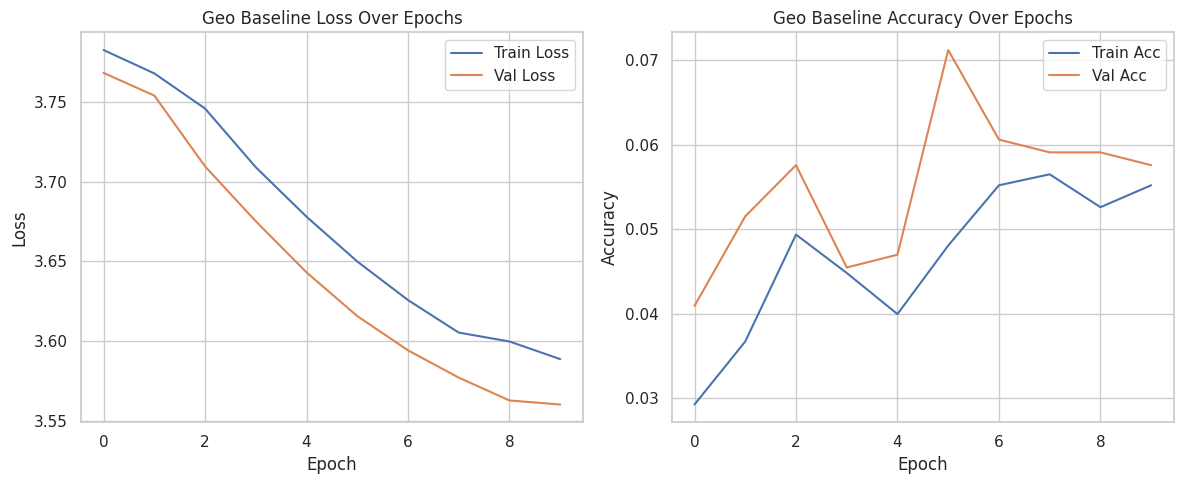

,species,count,correct,accuracy
0,Achillea millefolium,15,0,0.0
1,Angelica capitellata,15,15,1.0
2,Angelica hendersonii,15,0,0.0
3,Anthriscus caucalis,15,0,0.0
4,Artemisia californica,15,0,0.0
5,Artemisia douglasiana,15,0,0.0
6,Arundo donax,15,0,0.0
7,Baccharis pilularis,15,0,0.0
8,Baccharis salicifolia,15,0,0.0
9,Briza maxima,15,0,0.0


Saved results to /content/drive/.shortcut-targets-by-id/14mf7EDoPcO9gaw3M9fNkxH4dB36lTpn-/Final_project_109B/results/geo_baseline_results.json
Achillea millefolium                     0/15 = 0.000
Angelica capitellata                     15/15 = 1.000
Angelica hendersonii                     0/15 = 0.000
Anthriscus caucalis                      0/15 = 0.000
Artemisia californica                    0/15 = 0.000
Artemisia douglasiana                    0/15 = 0.000
Arundo donax                             0/15 = 0.000
Baccharis pilularis                      0/15 = 0.000
Baccharis salicifolia                    0/15 = 0.000
Briza maxima                             0/15 = 0.000
Briza minor                              0/15 = 0.000
Bromus hordeaceus                        3/15 = 0.200
Bromus rubens                            0/15 = 0.000
Cenchrus setaceus                        0/15 = 0.000
Centaurea solstitialis                   0/15 = 0.000
Cirsium vulgare                          0/15 

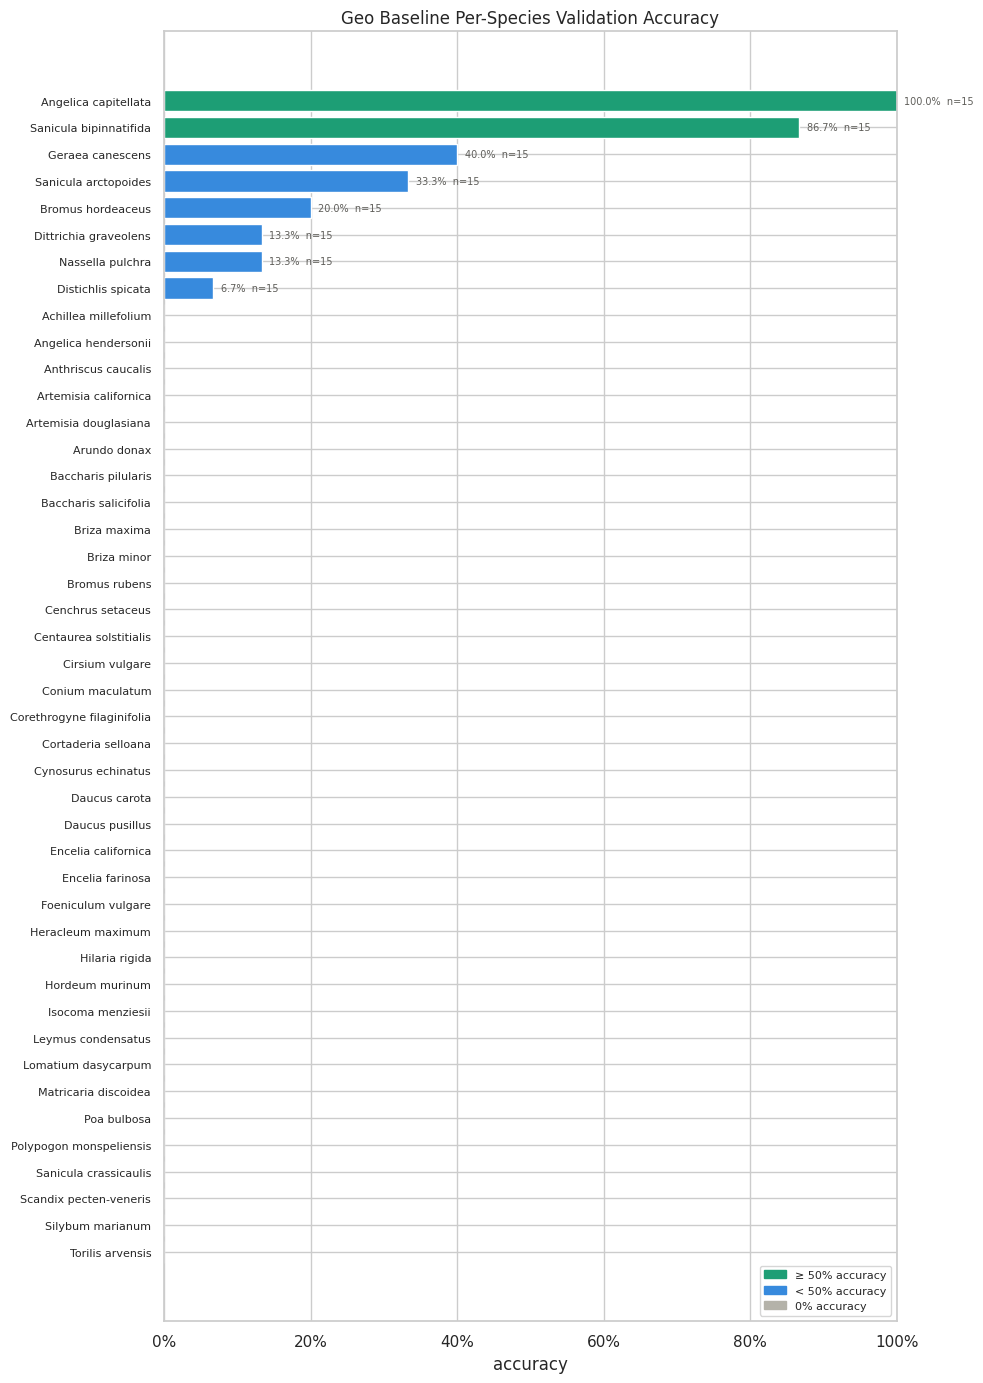

In [20]:
def plot_training_history(history, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title_prefix} Loss Over Epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{title_prefix} Accuracy Over Epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def build_species_results(metrics, label_encoder):
    species_results = []
    preds = metrics["preds"]
    labels = metrics["labels"]

    for i in range(len(label_encoder.classes_)):
        correct = int(((preds == labels) & (labels == i)).sum())
        total = int((labels == i).sum())
        species_results.append(
            {
                "name": label_encoder.inverse_transform([i])[0],
                "acc": round(correct / total, 3) if total > 0 else 0,
                "total": total,
                "correct": correct,
            }
        )

    species_results.sort(key=lambda x: x["acc"], reverse=True)
    return species_results


def print_species_accuracy(metrics, label_encoder):
    preds = metrics["preds"]
    labels = metrics["labels"]
    for i in range(len(label_encoder.classes_)):
        total = int((labels == i).sum())
        correct = int(((preds == labels) & (labels == i)).sum())
        acc = correct / total if total > 0 else 0
        print(f"{label_encoder.inverse_transform([i])[0]:<40} {correct}/{total} = {acc:.3f}")


def plot_species_accuracy_bar(species_results, title, save_path=None):
    names = [s["name"] for s in species_results]
    accs = [s["acc"] for s in species_results]
    tots = [s["total"] for s in species_results]

    colors = []
    for a in accs:
        if a == 0:
            colors.append("#B4B2A9")
        elif a >= 0.5:
            colors.append("#1D9E75")
        else:
            colors.append("#378ADD")

    fig, ax = plt.subplots(figsize=(10, 14))
    bars = ax.barh(names, accs, color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel("accuracy")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=8)

    for bar, acc, total in zip(bars, accs, tots):
        if acc > 0:
            ax.text(
                acc + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{acc:.1%}  n={total}",
                va="center",
                fontsize=7,
                color="#5F5E5A",
            )

    legend_patches = [
        mpatches.Patch(color="#1D9E75", label="≥ 50% accuracy"),
        mpatches.Patch(color="#378ADD", label="< 50% accuracy"),
        mpatches.Patch(color="#B4B2A9", label="0% accuracy"),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc="lower right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


if geo_history is not None:
    plot_training_history(geo_history, "Geo Baseline")
else:
    print("geo_history not found. Run the geo baseline training cell first.")

geo_eval_model = geo_model if geo_history is not None else None
if geo_eval_model is not None:
    geo_criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    geo_val_metrics = evaluate_classifier(geo_eval_model, geo_val_loader, geo_criterion, device=DEVICE)
    save_test_results("geo_baseline", geo_val_metrics, le)
    print_species_accuracy(geo_val_metrics, le)
    geo_species_results = build_species_results(geo_val_metrics, le)
    plot_species_accuracy_bar(
        geo_species_results,
        "Geo Baseline Per-Species Validation Accuracy",
        save_path=RESULTS_DIR / "geo_baseline_per_species_accuracy.png",
    )
else:
    print("Geo baseline model not found. Train or load the geo baseline first.")


### Geo Baseline Result Summary

The geo/time-only model is currently best understood as a weak but informative metadata baseline. Its validation accuracy is low, and most species have near-zero per-species accuracy. The few high-accuracy species may be geographically or seasonally concentrated, but the validation support is small in the matched subset.

This result is useful because it establishes a lower bound: location and season alone are not enough for reliable fine-grained classification on the current image-available subset. The result also motivates a separate full-observation geo baseline, because the current matched subset inherits the image sampling cap and therefore underuses the available geographic data.


## Stage 15. Image Baseline Analysis

### Goal

Evaluate how much species-discriminative signal is available from image content alone.

### Method

The analysis mirrors the geo baseline: training history is plotted, the best checkpoint is evaluated, per-species accuracy is printed, and the per-species figure is saved to `results/`.

### How To Read The Result

The image baseline is much stronger than the matched geo/time baseline, with the current checkpoint reaching about 44.8% best validation accuracy. Because only the ResNet50 classification head is trained, this is still a conservative visual baseline rather than a fully fine-tuned image model.

### Interpretation

Species with distinctive morphology should perform better visually, while visually similar grasses, composites, and umbellifers may remain difficult. Per-species image errors are especially useful for identifying candidate species pairs where a future multimodal model might benefit from geographic or seasonal priors.


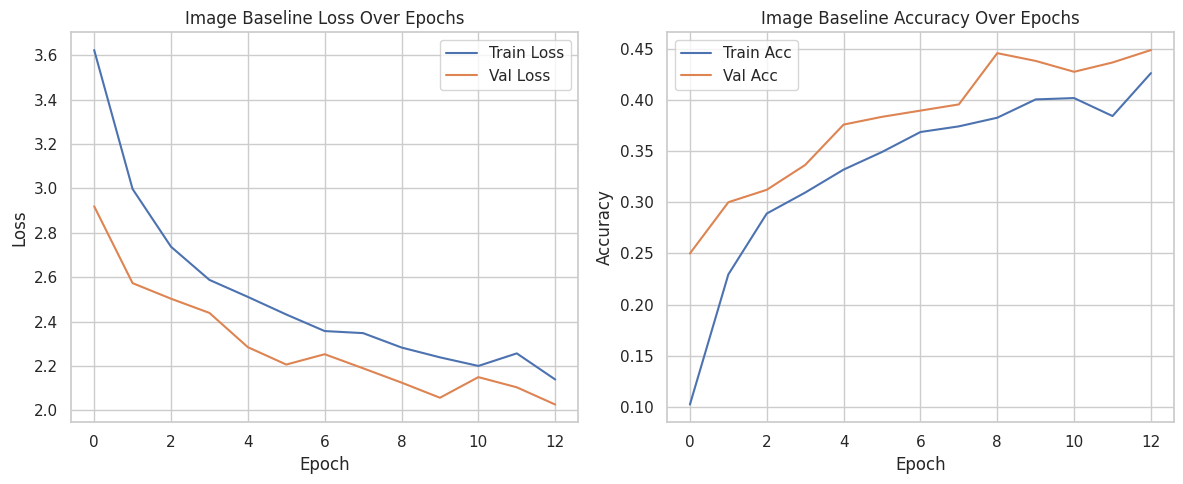

Achillea millefolium                     8/15 = 0.533
Angelica capitellata                     7/15 = 0.467
Angelica hendersonii                     8/15 = 0.533
Anthriscus caucalis                      3/15 = 0.200
Artemisia californica                    2/15 = 0.133
Artemisia douglasiana                    4/15 = 0.267
Arundo donax                             10/15 = 0.667
Baccharis pilularis                      6/15 = 0.400
Baccharis salicifolia                    2/15 = 0.133
Briza maxima                             11/15 = 0.733
Briza minor                              8/15 = 0.533
Bromus hordeaceus                        5/15 = 0.333
Bromus rubens                            6/15 = 0.400
Cenchrus setaceus                        10/15 = 0.667
Centaurea solstitialis                   14/15 = 0.933
Cirsium vulgare                          11/15 = 0.733
Conium maculatum                         8/15 = 0.533
Corethrogyne filaginifolia               3/15 = 0.200
Cortaderia selloana    

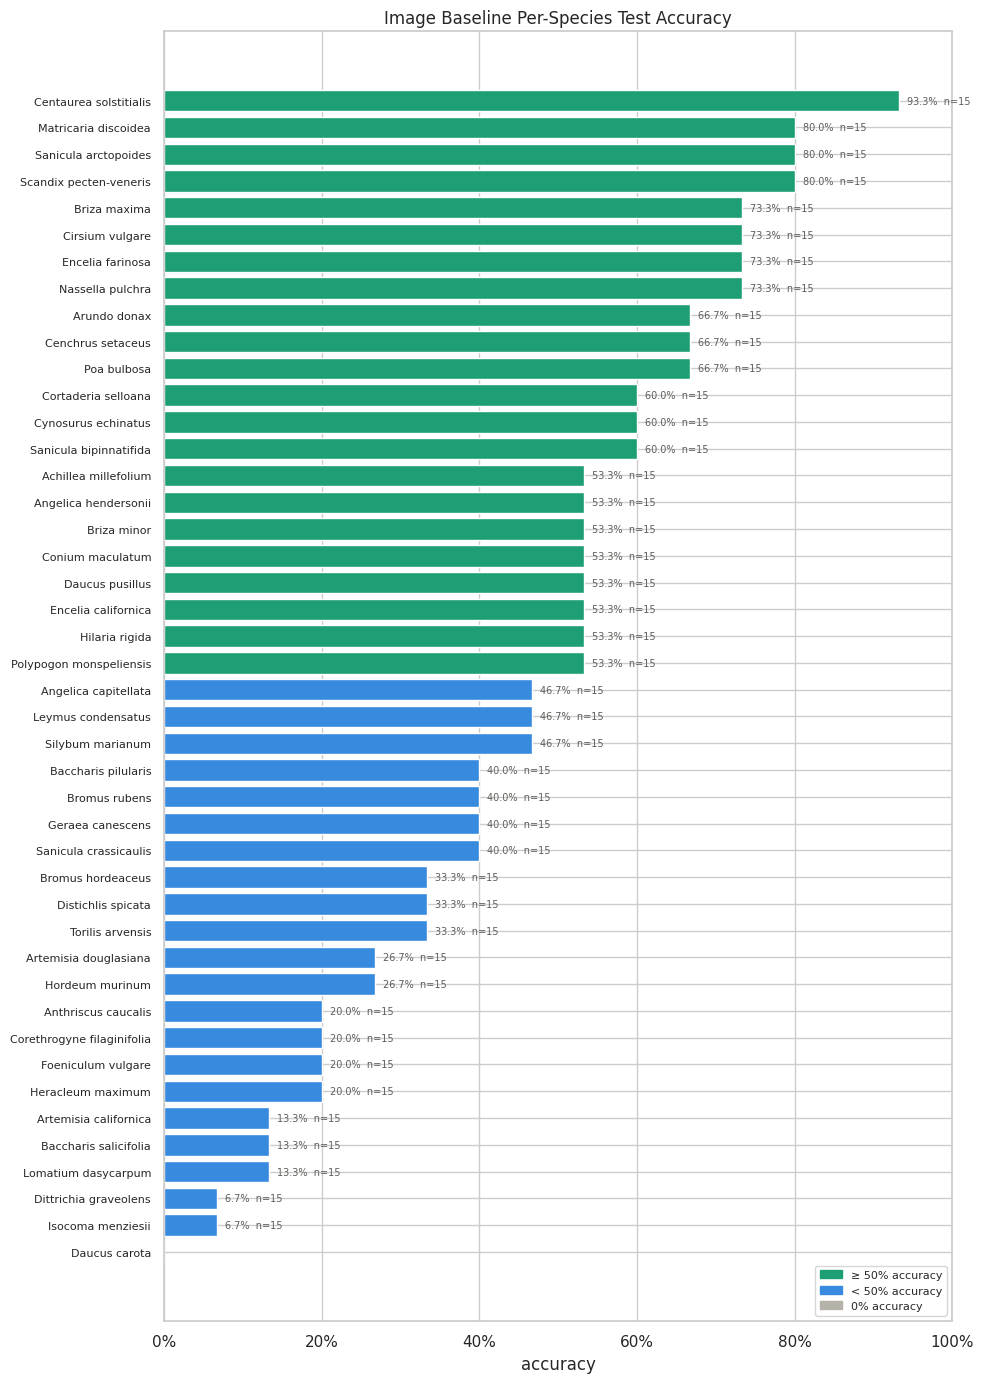

In [21]:
if img_history is not None:
    plot_training_history(img_history, "Image Baseline")
else:
    print("img_history not found. Run the image baseline training cell first.")

img_eval_model = model_simple_tune if img_history is not None else None
if img_eval_model is not None:
    image_test_metrics = evaluate_classifier(img_eval_model, test_image_loader, img_criterion, device=DEVICE)
    print_species_accuracy(image_test_metrics, le)
    image_species_results = build_species_results(image_test_metrics, le)
    plot_species_accuracy_bar(
        image_species_results,
        "Image Baseline Per-Species Test Accuracy",
        save_path=RESULTS_DIR / "image_baseline_per_species_accuracy.png",
    )
else:
    print("Image baseline model not found. Train or load the image baseline first.")


### Image Baseline Result Summary

The image-only baseline is the strongest completed baseline in this notebook. Even with only the final ResNet50 layer trained, it substantially outperforms the geo/time-only model. This suggests that visible morphology carries the dominant classification signal for the current dataset.

The most important follow-up is not only to improve overall image accuracy, but to inspect which species remain difficult. Those difficult visual confusions are the strongest candidates for testing whether geo/time context improves a future multimodal classifier.


## Final Notes

### Main Experimental Recommendation

Use the IID split in this notebook as the main matched benchmark for comparing image-only, geo/time-only, and future image-plus-context models on the same observations.

### Cross-Model Interpretation

The current results show a clear gap: the image baseline is much stronger than the matched geo/time-only baseline. This supports using image content as the primary classifier and treating geography/season as auxiliary context rather than a replacement for visual evidence.

### Important Caveat

The geo/time-only model in this notebook is intentionally matched to the image-available subset. That makes it fair for comparing input modalities on the same rows, but it also limits the geographic baseline to the image sampling design. A separate full-observation geo baseline should be added if the goal is to estimate the maximum predictive value of location and season across all downloaded GBIF/iNaturalist observations.
